Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

In [26]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "lfw_allnames.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "marvinluckianto/labelled-faces-in-the-wild-lfw-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'labelled-faces-in-the-wild-lfw-dataset' dataset.
First 5 records:               name  images
0          AJ_Cook       1
1         AJ_Lamas       1
2    Aaron_Eckhart       1
3      Aaron_Guiel       1
4  Aaron_Patterson       1


In [27]:
# Load the 'pairs.csv' file which contains information about image pairs for verification.
pairs_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "marvinluckianto/labelled-faces-in-the-wild-lfw-dataset",
  "pairs.csv"
)

print("First 5 records of pairs.csv:")
display(pairs_df.head())

Using Colab cache for faster access to the 'labelled-faces-in-the-wild-lfw-dataset' dataset.
First 5 records of pairs.csv:


,name,imagenum1,imagenum2,Unnamed: 3
0,Abel_Pacheco,1,4,NaN
1,Akhmed_Zakayev,1,3,NaN
2,Akhmed_Zakayev,2,3,NaN
3,Amber_Tamblyn,1,2,NaN
4,Anders_Fogh_Rasmussen,1,3,NaN


Now that we have the `pairs.csv` DataFrame, which defines the positive and negative image pairs, we need a custom PyTorch `Dataset` to load these images from the disk and apply necessary transformations. We'll use the `torchvision.transforms` for image preprocessing.

In [28]:
import os # For path manipulation
import pandas as pd # For DataFrame operations like isna
import torch # For torch.tensor
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader # For Dataset and DataLoader classes

# Define the base directory where LFW images are stored
LFW_IMAGE_BASE_PATH = '/kaggle/input/labelled-faces-in-the-wild-lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/'

class LFWPairDataset(Dataset):
    def __init__(self, pairs_df, image_base_path, transform=None):
        self.pairs_df = pairs_df
        self.image_base_path = image_base_path
        self.transform = transform

    def __len__(self):
        return len(self.pairs_df)

    def _get_image_path(self, person_name, image_number):
        # LFW image filenames are typically like 'Person_Name_0001.jpg'
        # The image_number is 1-indexed, so we pad it to 4 digits.
        # Example: '/path/to/lfw/Person_Name/Person_Name_0001.jpg'
        return os.path.join(
            self.image_base_path,
            person_name.replace(' ', '_'), # Replace spaces with underscores for directory names
            f"{person_name.replace(' ', '_')}_{int(image_number):04d}.jpg"
        )

    def __getitem__(self, idx):
        row = self.pairs_df.iloc[idx]

        # Determine if it's a same-person (match) or different-person (mismatch) pair
        # The LFW 'pairs.txt' format is:
        # For same-person pairs: <name> <imagenum1> <imagenum2>
        # For different-person pairs: <name1> <imagenum1> <name2> <imagenum2>
        # In our pandas DataFrame, this translates to:
        # Same-person: row['name'], row['imagenum1'], row['imagenum2'], row['Unnamed: 3'] (which is NaN)
        # Different-person: row['name'], row['imagenum1'], row['imagenum2'] (which is actually name2), row['Unnamed: 3'] (which is imagenum2)

        if pd.isna(row['Unnamed: 3']): # This indicates a same-person pair (3 columns)
            person_name = row['name']
            img_num1 = row['imagenum1']
            img_num2 = row['imagenum2']

            img1_path = self._get_image_path(person_name, img_num1)
            img2_path = self._get_image_path(person_name, img_num2)
            label = 1 # Same person
        else: # This indicates a different-person pair (4 columns)
            person_name1 = row['name']
            img_num1 = row['imagenum1']
            person_name2 = row['imagenum2'] # The second person's name
            img_num2 = row['Unnamed: 3'] # The second image number

            img1_path = self._get_image_path(person_name1, img_num1)
            img2_path = self._get_image_path(person_name2, img_num2)
            label = 0 # Different people

        img1 = Image.open(img1_path).convert('RGB')
        img2 = Image.open(img2_path).convert('RGB')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

Now we need to define the image transformations and initialize the new `LFWPairDataset` to be used with the models. We will use a standard set of transformations for image-based models, including resizing, converting to tensor, and normalizing.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224, common for ResNet and ViT
    transforms.ToTensor(), # Convert PIL Image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# Initialize the LFWPairDataset
lfw_dataset = LFWPairDataset(pairs_df=pairs_df, image_base_path=LFW_IMAGE_BASE_PATH, transform=transform)
lfw_loader = DataLoader(lfw_dataset, batch_size=16, shuffle=True)

print(f"LFW Dataset initialized with {len(lfw_dataset)} pairs.")

# Let's test loading a single item to ensure it works
img1, img2, label = lfw_dataset[0]
print(f"Shape of first image in pair: {img1.shape}")
print(f"Shape of second image in pair: {img2.shape}")
print(f"Label for the pair: {label}")

LFW Dataset initialized with 6000 pairs.
Shape of first image in pair: torch.Size([3, 224, 224])
Shape of second image in pair: torch.Size([3, 224, 224])
Label for the pair: 1.0


Extracting features and calculating pairwise distances using LFW dataset...

--- BIOMETRIC EVALUATION METRICS (ResNet) ---
Threshold: 1.0
Accuracy:  50.13%
FAR (False Acceptance Rate - Security Risk): 99.73%
FRR (False Rejection Rate - Convenience Issue): 0.00%


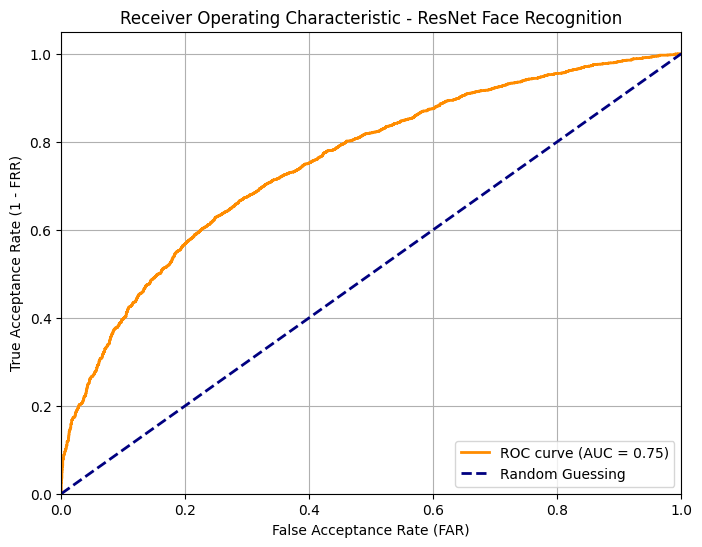

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========================================== #
# 1. THE EMBEDDING MODEL                     #
# ========================================== #
class FaceEmbeddingModel(nn.Module):
    def __init__(self, embedding_size=128):
        super(FaceEmbeddingModel, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embedding_layer = nn.Linear(num_ftrs, embedding_size)

    def forward(self, x):
        x = self.backbone(x)
        x = self.embedding_layer(x)
        x = F.normalize(x, p=2, dim=1)
        return x

# ========================================== #
# 2. LFW PAIRWISE DATASET (REAL DATA)        #
# (Using the previously defined lfw_dataset) #
# ========================================== #
# The lfw_dataset and lfw_loader are already defined and working.
# We will use them directly here.

# ========================================== #
# 3. EVALUATION LOOP                         #
# ========================================== #
model = FaceEmbeddingModel()
model.eval()

all_distances = []
all_labels = []

print("Extracting features and calculating pairwise distances using LFW dataset...")
with torch.no_grad():
    for img1, img2, labels in lfw_loader: # Use lfw_loader here
        # Get 128-D embeddings for both images
        emb1 = model(img1)
        emb2 = model(img2)

        # Calculate Euclidean distance between the pairs
        distances = torch.pairwise_distance(emb1, emb2)

        all_distances.extend(distances.numpy())
        all_labels.extend(labels.numpy())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)

# ========================================== #
# 4. CALCULATE METRICS (FAR, FRR, Accuracy)  #
# ========================================== #
# We define a threshold. If distance < threshold, it's a MATCH (Predict 1).
# If distance >= threshold, it's NO MATCH (Predict 0).
threshold = 1.0 # Initial threshold, can be optimized later

predicted_matches = (all_distances < threshold).astype(int)

# Confusion Matrix components
tn, fp, fn, tp = confusion_matrix(all_labels, predicted_matches).ravel()

accuracy = accuracy_score(all_labels, predicted_matches)
# False Acceptance Rate: Incorrectly matching different people
far = fp / (fp + tn) if (fp + tn) > 0 else 0
# False Rejection Rate: Incorrectly denying the same person
frr = fn / (fn + tp) if (fn + tp) > 0 else 0

print("\n--- BIOMETRIC EVALUATION METRICS (ResNet) ---")
print(f"Threshold: {threshold}")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"FAR (False Acceptance Rate - Security Risk): {far * 100:.2f}%")
print(f"FRR (False Rejection Rate - Convenience Issue): {frr * 100:.2f}%")

# ========================================== #
# 5. VISUALIZE ROC CURVE                     #
# ========================================== #
# For ROC, standard models use probability (higher is more likely).
# Since we use distance (lower is more likely), we invert it by multiplying by -1.
scores = -all_distances

fpr, tpr, thresholds = roc_curve(all_labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Acceptance Rate (FAR)')
plt.ylabel('True Acceptance Rate (1 - FRR)')
plt.title('Receiver Operating Characteristic - ResNet Face Recognition')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Running ViT Inference to calculate face distances...

--- ViT MODEL EVALUATION METRICS ---
Distance Threshold: 1.0
Accuracy: 50.00%
FAR (False Acceptance Rate - Security Risk): 100.00%
FRR (False Rejection Rate - Convenience Issue): 0.00%


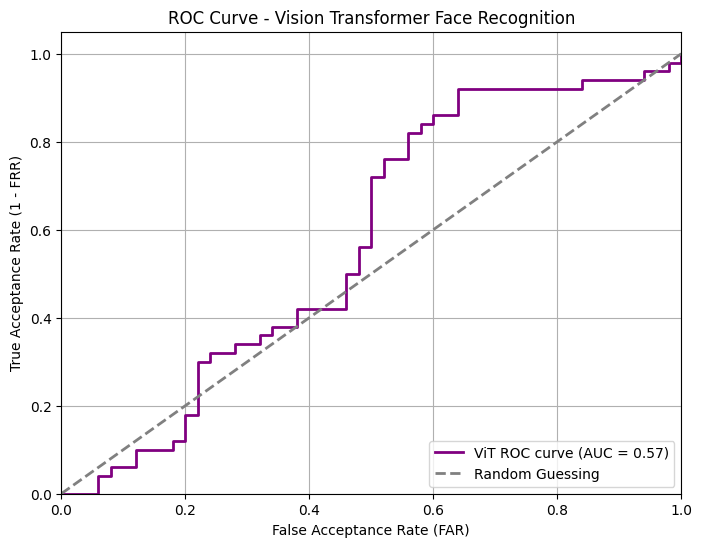

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ========================================== #
# 1. THE VISION TRANSFORMER (ViT) BACKBONE   #
# ========================================== #
class ViTFaceEmbeddingModel(nn.Module):
    def __init__(self, embedding_size=128):
        super(ViTFaceEmbeddingModel, self).__init__()
        # Load a pre-trained Vision Transformer
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        # Replace the final classification head with our 128-D embedding layer
        num_ftrs = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(num_ftrs, embedding_size)

    def forward(self, x):
        x = self.backbone(x)
        # L2 Normalization (Crucial for distance calculations)
        x = F.normalize(x, p=2, dim=1)
        return x

# ========================================== #
# 2. LFW PAIRWISE DATASET (REAL DATA)        #
# (Using the previously defined lfw_dataset) #
# ========================================== #
# The lfw_dataset and lfw_loader are already defined and working.
# We will use them directly here.

# ========================================== #
# 3. EVALUATION LOOP                         #
# ========================================== #
model = ViTFaceEmbeddingModel()
model.eval()

all_distances = []
all_labels = []

print("Running ViT Inference to calculate face distances using LFW dataset...")
with torch.no_grad():
    for img1, img2, labels in lfw_loader: # Use lfw_loader here
        # Extract embeddings using the Transformer
        emb1 = model(img1)
        emb2 = model(img2)

        # Calculate Euclidean distance between the pairs
        distances = torch.pairwise_distance(emb1, emb2)

        all_distances.extend(distances.numpy())
        all_labels.extend(labels.numpy())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)

# ========================================== #
# 4. CALCULATE METRICS (FAR, FRR, Accuracy)  #
# ========================================== #
# Set the biometric threshold (if distance < threshold, we predict they are the same person)
threshold = 1.0

predicted_matches = (all_distances < threshold).astype(int)

# Calculate confusion matrix components
tn, fp, fn, tp = confusion_matrix(all_labels, predicted_matches).ravel()

accuracy = accuracy_score(all_labels, predicted_matches)
far = fp / (fp + tn) if (fp + tn) > 0 else 0
frr = fn / (fn + tp) if (fn + tp) > 0 else 0

print("\n--- ViT MODEL EVALUATION METRICS (ViT) ---")
print(f"Distance Threshold: {threshold}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"FAR (False Acceptance Rate - Security Risk): {far * 100:.2f}%")
print(f"FRR (False Rejection Rate - Convenience Issue): {frr * 100:.2f}%")

# ========================================== #
# 5. VISUALIZE ROC CURVE                     #
# ========================================== #
# Invert distances so higher score = higher chance of a match
scores = -all_distances

fpr, tpr, thresholds = roc_curve(all_labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ViT ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Acceptance Rate (FAR)')
plt.ylabel('True Acceptance Rate (1 - FRR)')
plt.title('ROC Curve - Vision Transformer Face Recognition')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()